In [13]:
import openmc
import numpy as np
import matplotlib.pyplot as plt


In [14]:
import sys
sys.path.append('..')

# ho modificato dal file PRATIC_materials l'ossigeno perchè non trova nelle librerie nucleari l'o18, quindi ho fatto al posto di "add_element("0",1) -> "add_nuclide("O16",1)

In [16]:
from PRATIC_materials import uo2_external, uo2_internal, uo2_central, uo2_poisoned, zircalloy, gap, water, AIC, steel


ImportError: cannot import name 'uo2_external' from 'PRATIC_materials' (/root/OpenMC/openmc/prova/PRATIC_materials.py)

In [ ]:
"""    Fuel rod     """
fuel_radius = 0.4107
gap_thickness = 0.0089         #0.4180-0.4095
cladding_thickness = 0.4757-0.4186

"""    Control rod e guide tube    """
absorber_rod_radius = 0.3844
absorber_rod_gap_thickness = 0.3879 - 0.3844
absorber_rod_cladding_thickness = 0.4863 - 0.3879 
guide_tube_in_radius = 0.5618
guide_tube_out_radius = 0.6029

"""    Instrumentation tube    """
instrumentation_tube_in_radius = 0.5598
instrumentation_tube_out_radius = 0.6059

pin_pitch = 1.2618
pin_height = 200
num_cells = 17
lattice_length = pin_pitch * num_cells # 21.5313 (assembly pitch) - 2*0.0095 (gap between fuel and clad)

env_radius = lattice_length/2 + 20 # raggio che circonda tutto il core

# Definizione Pin

Fuel rod

In [ ]:
"""    Geometria    """
fuel_cyl = openmc.ZCylinder(r=fuel_radius)
gap_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness)
clad_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness + cladding_thickness)

"""    Regioni    """
fuel_region = -fuel_cyl 
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl 


"""    Celle    """
fuel_cell_internal = openmc.Cell(region=fuel_region, fill=uo2_internal)
fuel_cell_central = openmc.Cell(region=fuel_region, fill=uo2_central)
fuel_cell_external = openmc.Cell(region=fuel_region, fill=uo2_external)
fuel_cell_poisoned = openmc.Cell(region=fuel_region, fill=uo2_poisoned)

gap_cell = openmc.Cell(region=gap_region, fill=gap)
clad_cell = openmc.Cell(region=clad_region, fill=zircalloy)
water_cell = openmc.Cell(region=water_region, fill=water)

"""    Universi    """
pin_universe_central = openmc.Universe(cells=[fuel_cell_central, gap_cell, clad_cell, water_cell])
pin_universe_internal = openmc.Universe(cells=[fuel_cell_internal, gap_cell, clad_cell, water_cell])
pin_universe_external = openmc.Universe(cells=[fuel_cell_external, gap_cell, clad_cell, water_cell])
pin_universe_poisoned = openmc.Universe(cells=[fuel_cell_poisoned, gap_cell, clad_cell, water_cell])


Guide tube _(control rod disinserite)_

In [ ]:
"""    Geometria    """
guide_in_cyl=openmc.ZCylinder(r=guide_tube_in_radius)
guide_out_cyl=openmc.ZCylinder(r=guide_tube_out_radius)

"""    Regioni    """
water_in_region=-guide_in_cyl
clad_tube_region=+guide_in_cyl & -guide_out_cyl
water_out_region=+guide_out_cyl

"""    Celle    """
water_in_tube_cell=openmc.Cell(region=water_in_region, fill=water)
clad_tube_cell=openmc.Cell(region=clad_tube_region, fill=zircalloy)
water_out_tube_cell=openmc.Cell(region=water_out_region, fill=water)

"""    Universi    """
guide_tube_universe=openmc.Universe(cells=[water_in_tube_cell, clad_tube_cell, water_out_tube_cell])


Guide tube _(control rod inserite)_

In [ ]:
"""    Geometria    """
absorber_cylinder = openmc.ZCylinder(r=absorber_rod_radius)
absorber_gap_cylinder = openmc.ZCylinder(r=absorber_rod_radius + absorber_rod_gap_thickness)
absorber_clad_cylinder = openmc.ZCylinder(r=absorber_rod_radius + absorber_rod_gap_thickness + absorber_rod_cladding_thickness)

"""    Regioni    """
absorber_region = - absorber_cylinder
abs_gap_region = + absorber_cylinder & - absorber_gap_cylinder
abs_clad_region = + absorber_gap_cylinder & - absorber_clad_cylinder
water_gap_region = + absorber_clad_cylinder & - guide_in_cyl

"""    Celle    """
AIC_cell = openmc.Cell(region=absorber_region, fill=AIC)
steel_cell = openmc.Cell(region=absorber_region, fill=steel)
abs_gap_cell = openmc.Cell(region = abs_gap_region, fill = gap)
abs_clad_cell = openmc.Cell(region = abs_clad_region, fill = steel)
water_gap_cell = openmc.Cell(region = water_gap_region, fill = water)

"""    Universi    """
AIC_rod_universe=openmc.Universe(cells=[AIC_cell, abs_gap_cell, abs_clad_cell, water_gap_cell, clad_tube_cell, water_out_tube_cell])
steel_rod_universe=openmc.Universe(cells=[steel_cell, abs_gap_cell, abs_clad_cell, water_gap_cell, clad_tube_cell, water_out_tube_cell])

Tubo per strumentazione _(Pin centrale di ogni assembly)_

In [ ]:
"""    Geometria    """
instrumentation_in_cyl=openmc.ZCylinder(r=instrumentation_tube_in_radius)
instrumentation_out_cyl=openmc.ZCylinder(r=instrumentation_tube_out_radius)

"""    Regioni    """   
water_in_instrumentation_region=-instrumentation_in_cyl
clad_tube_instrumentation_region=+instrumentation_in_cyl & -instrumentation_out_cyl
water_out_instrumentation_region=+instrumentation_out_cyl

"""    Celle    """
water_in_instrumentation_cell=openmc.Cell(region=water_in_instrumentation_region, fill=water)
clad_tube_instrumentation_cell=openmc.Cell(region=clad_tube_instrumentation_region, fill=zircalloy)
water_out_instrumentation_cell=openmc.Cell(region=water_out_instrumentation_region, fill=water) 

"""    Universi    """
instrumentation_tube_universe=openmc.Universe(cells=[water_in_instrumentation_cell, clad_tube_instrumentation_cell, water_out_instrumentation_cell])

# Definizione Assembly

In [ ]:
upper_surface=openmc.ZPlane(z0=pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no
lower_surface=openmc.ZPlane(z0=-pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no

# Il canale per la strumentazione è sempre la pin centrale dell'assembly
x_instrumentation=np.array([8])
y_instrumentation=np.array([8])

## _Control rod completamente disinserite_
  ($k_{eff}$ massimo)

In [ ]:
# NB: i guide tube e il canale per la strumentazione hanno le stesse
#     coordinate in tutti gli assembly, e in questo caso sono uguali 
#     in tutti gli assembly, quindi basta definirli una volta sola

x_guide_tube=np.array([2,2,2,3,3,5,5,5,5,5,8,8,8,8,11,11,11,11,11,13,13,14,14,14])
y_guide_tube=np.array([5,8,11,3,13,2,5,8,11,14,2,5,11,14,2,5,8,11,14,3,13,5,8,11])

Centrale

In [ ]:
# Posizioni dei pin avvelenati
x_poisoned=np.array([3,3,6,6,10,10,13,13])
y_poisoned=np.array([6,10,3,13,3,13,6,10])

# Definizione del lattice
central_lattice=openmc.RectLattice()
central_lattice.lower_left = (-lattice_length/2, -lattice_length/2)                 # Versione alternativa con un ciclo for
central_lattice.pitch = (pin_pitch, pin_pitch)                                      # 
central_lattice.universes= [[pin_universe_central]*num_cells]*num_cells             # for x, y in zip(x_poisoned, y_poisoned):
central_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned           #    central_lattice.universes[x][y] = pin_universe_poisoned
central_lattice.universes[x_guide_tube, y_guide_tube] = guide_tube_universe
central_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
central_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

# Creazione dell'universo assembly
central_assembly_region = -upper_surface & +lower_surface
central_assembly_cell = openmc.Cell(region=central_assembly_region, fill=central_lattice)
central_assembly_universe = openmc.Universe(cells=[central_assembly_cell])

Interna

In [ ]:
# Posizioni dei pin avvelenati
x_poisoned=np.array([1,1,1,2,2,3,3,4,4,4,4,4,6,6,6,6,8,8,8,8,10,10,10,10,12,12,12,12,12,13,13,14,14,15,15,15])
y_poisoned=np.array([4,8,12,2,14,6,10,1,4,8,12,15,3,6,10,13,1,4,12,15,3,6,10,13,1,4,8,12,15,6,10,2,14,4,8,12])

# Definizione del lattice
internal_lattice=openmc.RectLattice()
internal_lattice.lower_left = (-lattice_length/2, -lattice_length/2)
internal_lattice.pitch = (pin_pitch, pin_pitch)
internal_lattice.universes= [[pin_universe_central]*num_cells]*num_cells
internal_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned 
internal_lattice.universes[x_guide_tube, y_guide_tube] = guide_tube_universe
internal_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
internal_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

# Creazione dell'universo assembly
internal_assembly_region = -upper_surface & +lower_surface
internal_assembly_cell = openmc.Cell(region=internal_assembly_region, fill=internal_lattice)
internal_assembly_universe = openmc.Universe(cells=[internal_assembly_cell])

Esterna

In [ ]:
# Posizioni dei pin avvelenati
x_poisoned=np.array([1,1,2,2,3,3,4,4,4,6,6,6,6,8,8,10,10,10,10,12,12,12,13,13,14,14,15,15])                             #ma porca puttana ho perso tutta la parte sugli exteranl assembly !!! (rabbia)
y_poisoned=np.array([4,12,2,14,6,10,1,8,15,3,6,10,13,4,12,3,6,10,13,1,8,15,6,10,2,14,4,12])

# Definizione del lattice
external_lattice=openmc.RectLattice()
external_lattice.lower_left = (-lattice_length/2, -lattice_length/2)
external_lattice.pitch = (pin_pitch, pin_pitch)
external_lattice.universes= [[pin_universe_central]*num_cells]*num_cells  #non dovrebbe dare problemi nel caso modificare gli indici indicando di che tipo di assembly fanno parte quindi da x_poisoned -> x_poisoned_external e così via
external_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned 
external_lattice.universes[x_guide_tube, y_guide_tube] = guide_tube_universe
external_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
external_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

# Creazione dell'universo assembly
external_assembly_region = -upper_surface & +lower_surface
external_assembly_cell = openmc.Cell(region=external_assembly_region, fill=external_lattice)
external_assembly_universe = openmc.Universe(cells=[external_assembly_cell])

# Core Lattice

In [ ]:
assembly_pitch = 21.5313
# inter_assembly_half_gap = 0.04035
core_length = assembly_pitch * 9 # 9 è il numero di assembly per lato
env_radius = core_length/2 + 30 # raggio che circonda tutto il core
core_height = 200

In [ ]:

# Superficie cilindrica laterale
outer_surface = openmc.ZCylinder(r=env_radius, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no

#assembly di acqua per "tagliare " i bordi del core
water_assembly_cell = openmc.Cell(region=central_assembly_region, fill=water)
water_assembly_universe = openmc.Universe(cells=[water_assembly_cell])

# Superfici piane per altezza (Z)
z_max = openmc.ZPlane(z0= core_height/2, boundary_type='reflective')
z_min = openmc.ZPlane(z0= -core_height/2, boundary_type='reflective')


In [ ]:
x_central = np.array([4])
y_central = np.array([4])

x_internal = np.array([1,2,3,3,3,4,4,4,4,4,4,5,5,5,6,7])
y_internal = np.array([4,4,3,4,5,1,2,3,5,6,7,3,4,5,4,4])

# questi due non sono necessari perchè ho già riempito il core lattice con gli external_assembly_universe
#x_external = np.array([4,5,6,3,4,6,7,2,3,4,6,7,8,1,2,3,7,8,9,1,9,1,2,3,7,8,9,2,3,4,6,7,8,3,4,6,7,4,5,6])
#y_external = np.array([1,1,1,2,2,2,2,3,3,3,3,3,3,4,4,4,4,4,4,5,5,6,6,6,6,6,6,7,7,7,7,7,7,8,8,8,8,9,9,9])

x_water_assembly= np.array([0,0,0,0,0,0,1,1,1,1,2,2,6,6,7,7,7,7,8,8,8,8,8,8])
y_water_assembly= np.array([0,1,2,6,7,8,0,1,7,8,0,8,0,8,0,1,7,8,0,1,2,6,7,8])

# Definizione del lattice
core_lattice = openmc.RectLattice()
core_lattice.lower_left = (-core_length/2, -core_length/2)
core_lattice.pitch = (assembly_pitch, assembly_pitch)
core_lattice.universes = [[external_assembly_universe]*9]*9
core_lattice.universes[x_central, y_central] = central_assembly_universe
core_lattice.universes[x_internal, y_internal] = internal_assembly_universe
#core_lattice.universes[x_external, y_external] = external_assembly_universe 
core_lattice.universes[x_water_assembly, y_water_assembly] = water_assembly_universe

#core_lattice.universes = lattice_array  #cosa fa questo comando?
core_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

# Crea una cella per contenere il lattice 
# che definisce i limiti esterni del nocciolo
core_region = -outer_surface & +z_min & -z_max
core_cell = openmc.Cell(region=core_region, fill=core_lattice)

core_universe = openmc.Universe(cells=[core_cell])


In [ ]:
# Esporta la geometria in un file XML
geometry_core = openmc.Geometry(core_universe)
geometry_core.export_to_xml()

In [ ]:
# Definizione del Plot
plot_core = openmc.Plot()
plot_core.filename = 'plot_core'
plot_core.basis = 'xy' 
plot_core.origin = (0, 0, 0)
plot_core.width = (2*core_length, 2*core_length) # Leggermente più grande del core
plot_core.pixels = (10000, 10000)
#plot_core.color_by = 'cell' 



"""
plot_core.colors = {
    central_assembly_cell: "red",
    internal_assembly_cell: "lightcoral",
    external_assembly_cell: "yellow",
}
"""
plot_core.color_by=('material')
plot_core.colors= {uo2_central: 'orange', uo2_external:'orange', uo2_internal:'orange', uo2_poisoned:'green', water:'lightblue' }

#prova di sezione del core
section_core= openmc.Plot()
section_core.filename = 'section_core'
section_core.basis = 'xz'
section_core.origin = (0, 0, 0)
section_core.width = (2*core_length, core_height) # Leggermente più grande del core
section_core.pixels = (2000, 2000)
section_core.color_by = 'cell'
section_core.colors = {
    central_assembly_cell: "red",
    internal_assembly_cell: "lightcoral",
    external_assembly_cell: "yellow",
    water_assembly_cell: "blue"
}

plots = openmc.Plots([plot_core, section_core])
plots.export_to_xml()
openmc.plot_geometry(output=True)

from IPython.display import Image
Image(filename='plot_core.png')



                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

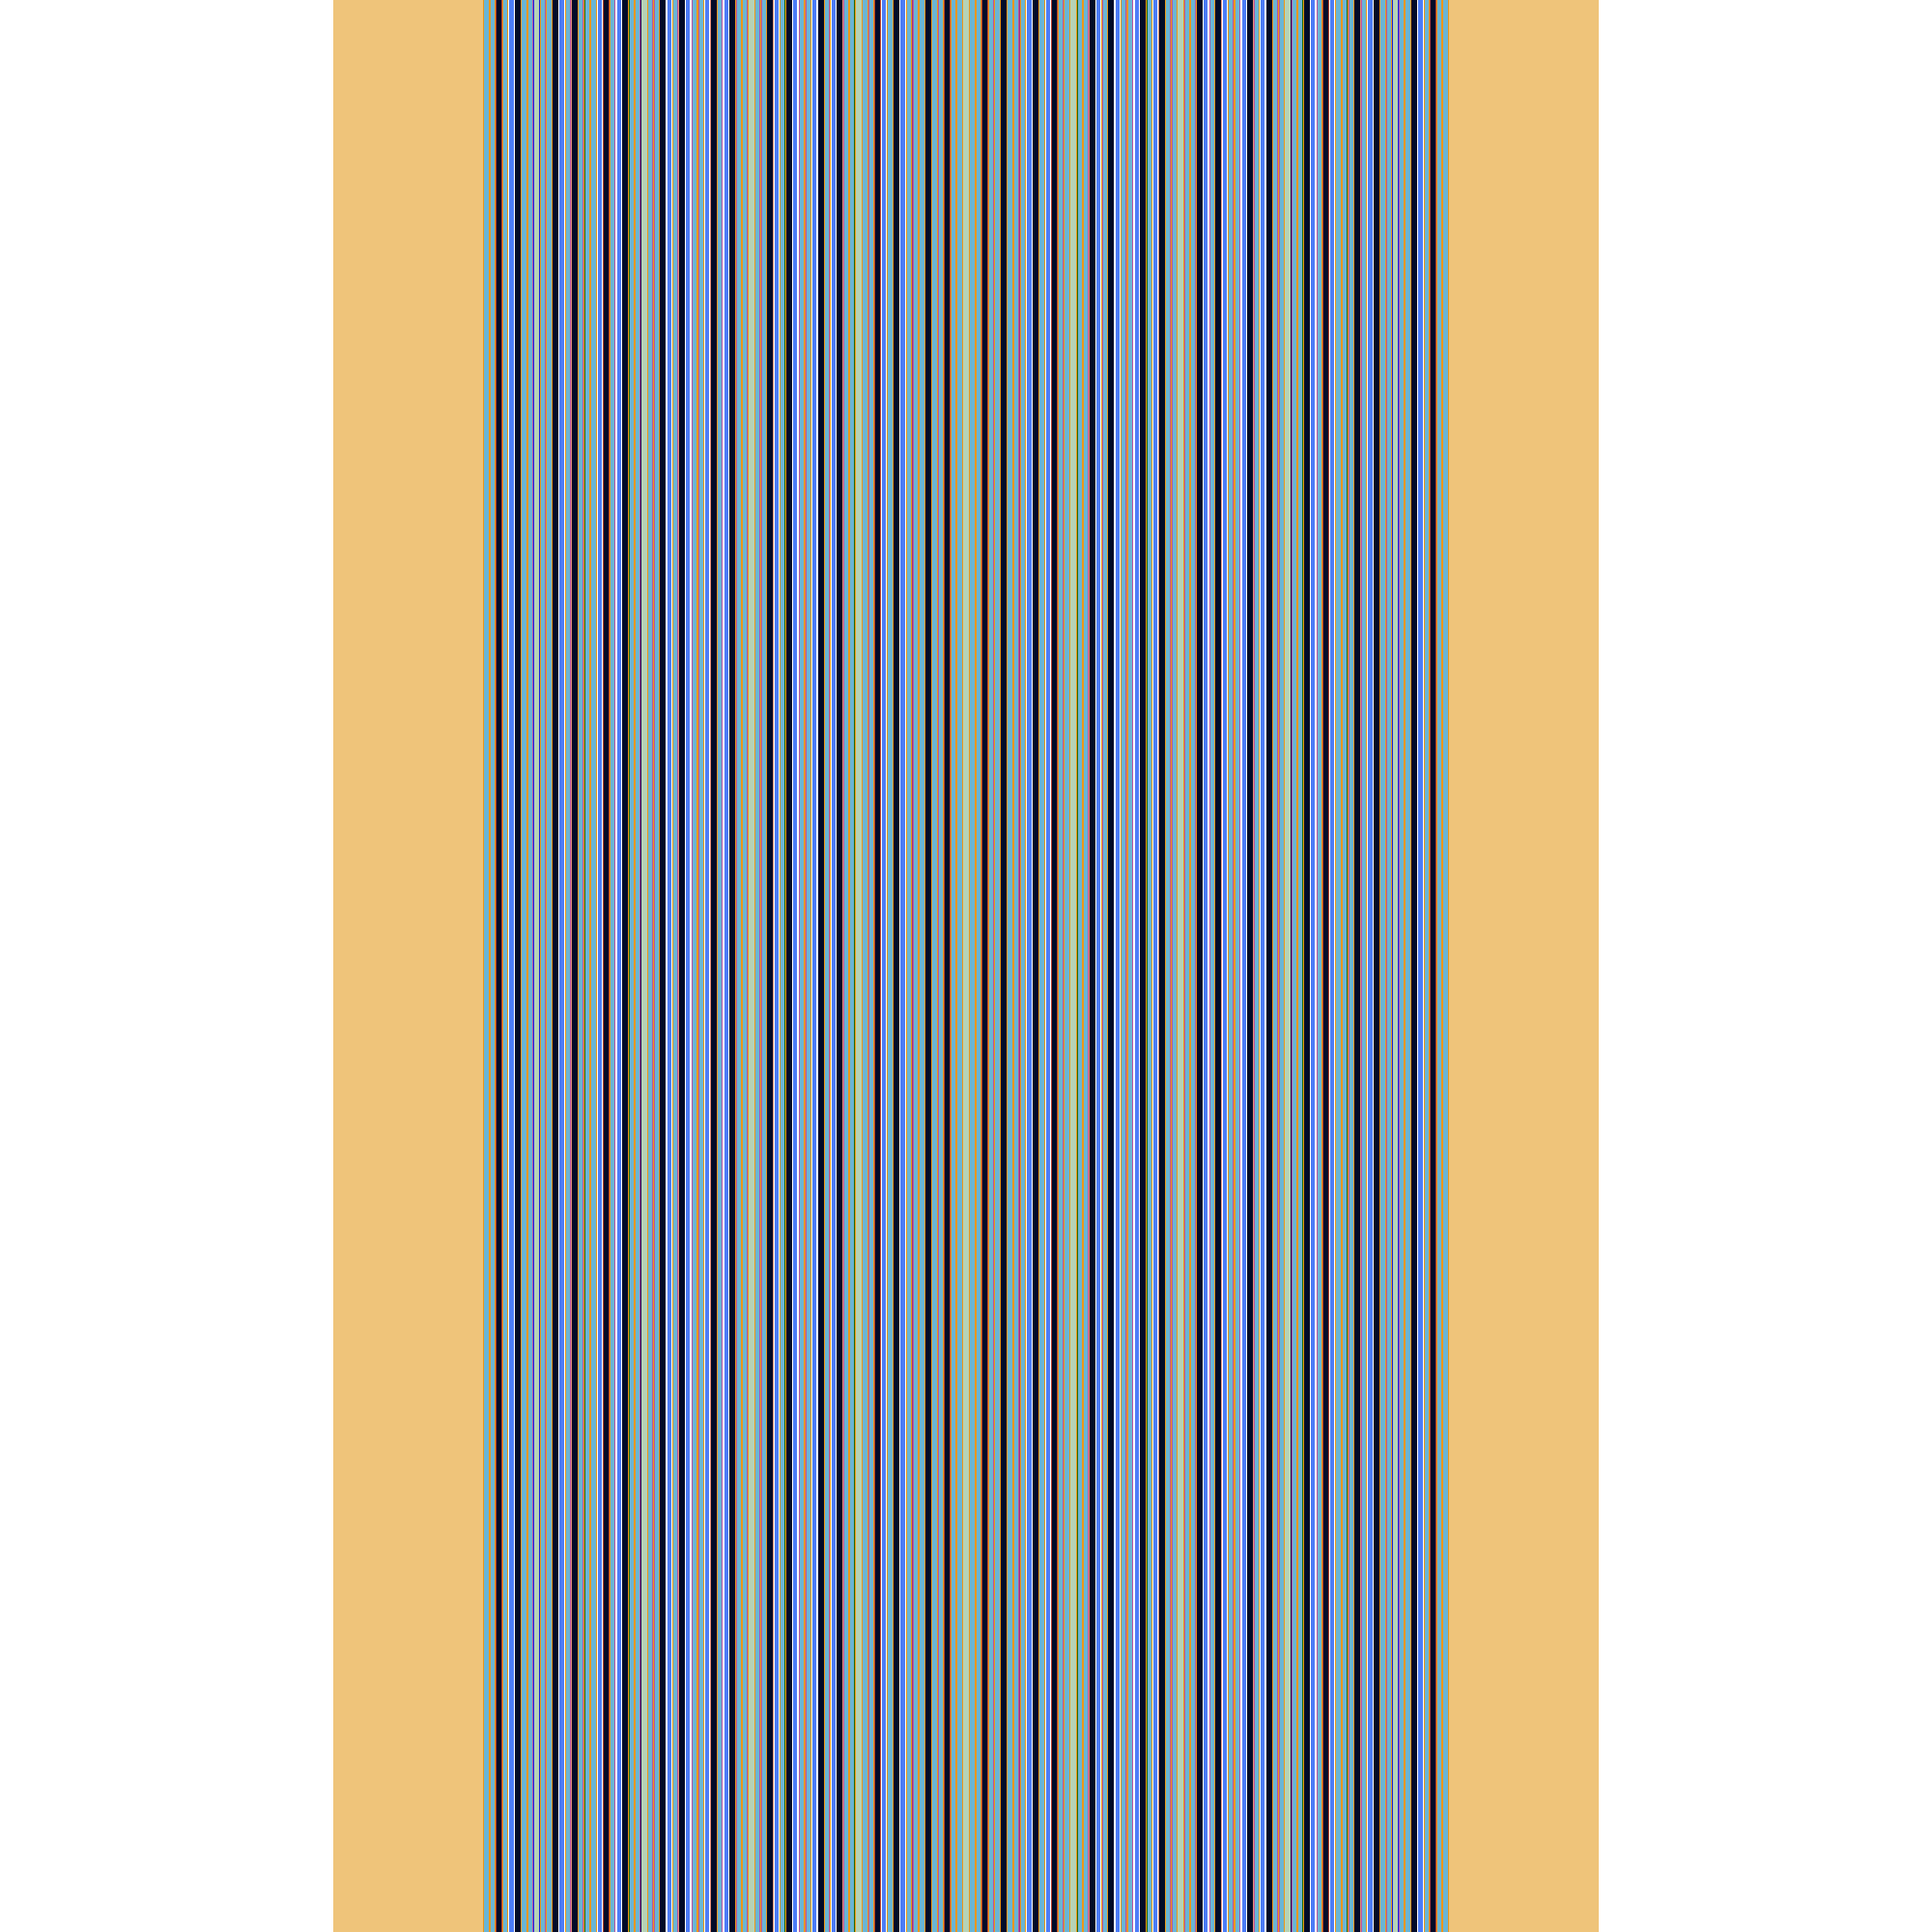

In [ ]:
from IPython.display import Image
Image(filename='section_core.png')

In [ ]:
# Aggiungi questo prima di openmc.run()
#openmc.run(geometry_debug=True)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 

# prossimo step prova di simulazione

In [ ]:
ll,ur = geometry_core.bounding_box
point = openmc.stats.Box(lower_left=ll, upper_right=ur) #oggetto preformato che mi restituisce una sorgente a scatola
source = openmc.IndependentSource(space=point, constraints={'fissionable':True }) #così da far partire solo i neutroni che partono da materiale fissionabile (quindi solo dal combustibile) e non da altri materiali (come il clad o l'acqua) che non hanno senso in questo caso

settings = openmc.Settings()
settings.geometry_debug = True 
settings.source = source
settings.batches = 80
settings.inactive = 10
settings.particles = 1000
settings.temperature = {"method": "interpolation"}

settings.export_to_xml()


In [ ]:
openmc.config["cross_sections"] = "/mnt/d/endfb-vii.1-hdf5/cross_sections.xml"

In [ ]:
#settings = openmc.Settings()
# Abilita il controllo della geometria all'avvio
#settings.geometry_debug = True 
# Esporta le impostazioni
#settings.export_to_xml()

# Ora quando lanci openmc, lui farà il controllo
openmc.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

RuntimeError: Need to specify number of particles. -------------------------------------------------------------------------- MPI_ABORT was invoked on rank 0 in communicator MPI_COMM_WORLD Proc: [[32447,0],0] Errorcode: -1 NOTE: invoking MPI_ABORT causes Open MPI to kill all MPI processes. You may or may not see output from other processes, depending on exactly when Open MPI kills them. --------------------------------------------------------------------------